In [1]:
# ============================================
# Customer Churn Prediction & Segmentation
# Week 1: Data Acquisition & Data Cleaning
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the IBM Telco Customer Churn dataset

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [12]:
# Display the first 5 rows

df.head()
# Check the dataset dimensions



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [6]:
# Display all column names

print("Column Names:")
print(df.columns.tolist())

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Generate descriptive statistics

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
# Display only columns containing missing values

missing_values = df.isnull().sum()

print("Columns with missing values:")
print(missing_values[missing_values > 0])

Columns with missing values:
Series([], dtype: int64)


In [10]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
# Find blank values in TotalCharges

blank_total_charges = df['TotalCharges'].str.strip().eq('').sum()

print("Blank TotalCharges values:", blank_total_charges)

Blank TotalCharges values: 11


In [14]:
# Convert TotalCharges from text to numeric

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("TotalCharges data type:", df['TotalCharges'].dtype)

TotalCharges data type: float64


In [15]:
# Check missing values after converting TotalCharges

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
TotalCharges    11
dtype: int64


In [16]:
# Inspect the rows where TotalCharges is missing

missing_total_charges = df[df['TotalCharges'].isnull()]

missing_total_charges

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [17]:
# Fill missing TotalCharges with 0
# Reason: all missing cases have tenure = 0

df['TotalCharges'] = df['TotalCharges'].fillna(0)

print("Missing TotalCharges after cleaning:",
      df['TotalCharges'].isnull().sum())

Missing TotalCharges after cleaning: 0


In [18]:
# Check the unique values in the Contract column

print(df['Contract'].unique())

['Month-to-month' 'One year' 'Two year']


In [19]:
# Check unique values in InternetService

print(df['InternetService'].unique())

['DSL' 'Fiber optic' 'No']


In [20]:
# Check the unique values in the Churn column

print(df['Churn'].unique())

['No' 'Yes']


In [21]:
# Identify categorical columns

categorical_columns = df.select_dtypes(include='object').columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [22]:
# Count unique values in each categorical column

for column in categorical_columns:
    print(column, "→", df[column].nunique(), "unique values")

customerID → 7043 unique values
gender → 2 unique values
Partner → 2 unique values
Dependents → 2 unique values
PhoneService → 2 unique values
MultipleLines → 3 unique values
InternetService → 3 unique values
OnlineSecurity → 3 unique values
OnlineBackup → 3 unique values
DeviceProtection → 3 unique values
TechSupport → 3 unique values
StreamingTV → 3 unique values
StreamingMovies → 3 unique values
Contract → 3 unique values
PaperlessBilling → 2 unique values
PaymentMethod → 4 unique values
Churn → 2 unique values


In [23]:
# Display unique values of each categorical column

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn:
['No' 'Yes']


In [24]:
# Identify numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [25]:
# Check minimum and maximum values of numerical columns

for column in numerical_columns:
    print(f"{column}:")
    print("Minimum =", df[column].min())
    print("Maximum =", df[column].max())
    print()

SeniorCitizen:
Minimum = 0
Maximum = 1

tenure:
Minimum = 0
Maximum = 72

MonthlyCharges:
Minimum = 18.25
Maximum = 118.75

TotalCharges:
Minimum = 0.0
Maximum = 8684.8



In [26]:
# Check for logically invalid numerical values

print("Negative tenure:", (df['tenure'] < 0).sum())
print("Negative MonthlyCharges:", (df['MonthlyCharges'] < 0).sum())
print("Negative TotalCharges:", (df['TotalCharges'] < 0).sum())

print("Invalid SeniorCitizen values:")
print(df.loc[~df['SeniorCitizen'].isin([0, 1]), 'SeniorCitizen'].unique())

Negative tenure: 0
Negative MonthlyCharges: 0
Negative TotalCharges: 0
Invalid SeniorCitizen values:
[]


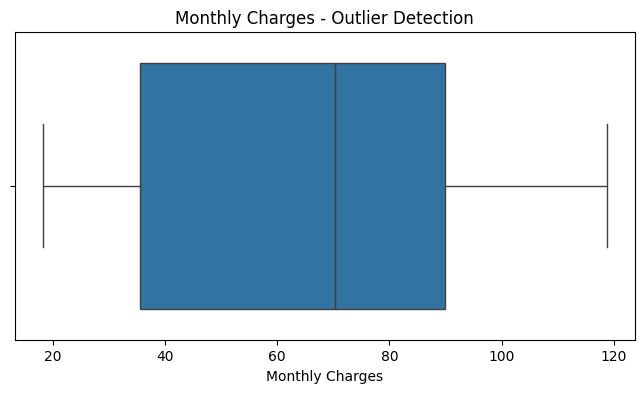

In [27]:
# Visualize MonthlyCharges to identify potential outliers

plt.figure(figsize=(8, 4))

sns.boxplot(x=df['MonthlyCharges'])

plt.title('Monthly Charges - Outlier Detection')
plt.xlabel('Monthly Charges')

plt.show()

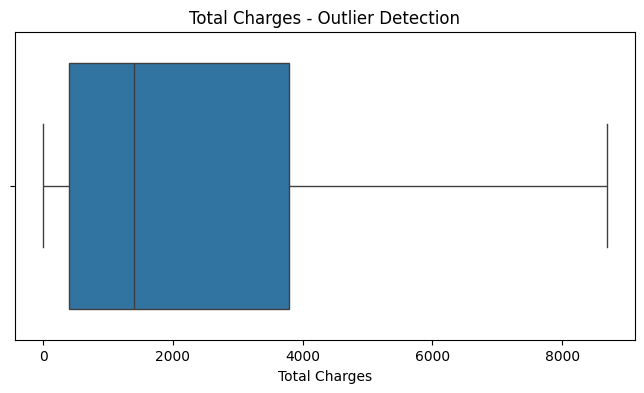

In [28]:
# Visualize TotalCharges to identify potential outliers

plt.figure(figsize=(8, 4))

sns.boxplot(x=df['TotalCharges'])

plt.title('Total Charges - Outlier Detection')
plt.xlabel('Total Charges')

plt.show()

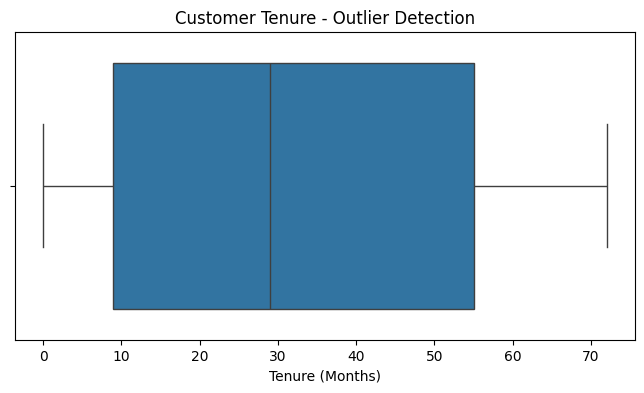

In [29]:
# Visualize tenure to identify potential outliers

plt.figure(figsize=(8, 4))

sns.boxplot(x=df['tenure'])

plt.title('Customer Tenure - Outlier Detection')
plt.xlabel('Tenure (Months)')

plt.show()

In [30]:
# Final verification after data cleaning

print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (7043, 21)

Missing values:
0

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [31]:
# Save the cleaned dataset

df.to_csv('telco_customer_churn_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [34]:
# Check for leading or trailing spaces in categorical columns

for column in categorical_columns:
    space_count = df[column].astype(str).str.strip().ne(
        df[column].astype(str)
    ).sum()

    if space_count > 0:
        print(column, "→", space_count, "values with extra spaces")

In [35]:
# Final data cleaning summary

print("========== DATA CLEANING SUMMARY ==========")

print("\nDataset:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values remaining:",
      df.isnull().sum().sum())

print("Duplicate rows remaining:",
      df.duplicated().sum())

print("\nData type of TotalCharges:",
      df['TotalCharges'].dtype)

print("\nCleaning performed:")
print("1. Converted TotalCharges from object to numeric")
print("2. Handled 11 missing TotalCharges values")
print("3. Checked for duplicate rows")
print("4. Checked categorical values")
print("5. Checked numerical validity")
print("6. Checked potential outliers")
print("7. Checked leading/trailing whitespace")

print("\n============================================")

========== DATA CLEANING SUMMARY ==========

Dataset:
Rows: 7043
Columns: 21

Missing values remaining: 0
Duplicate rows remaining: 0

Data type of TotalCharges: float64

Cleaning performed:
1. Converted TotalCharges from object to numeric
2. Handled 11 missing TotalCharges values
3. Checked for duplicate rows
4. Checked categorical values
5. Checked numerical validity
6. Checked potential outliers
7. Checked leading/trailing whitespace



## Data Cleaning Summary

The IBM Telco Customer Churn dataset initially contained 7,043 customer records and 21 columns.

The dataset was inspected for missing values, duplicate records, incorrect data types, inconsistent categorical values, invalid numerical values, and potential outliers.

During the inspection, the `TotalCharges` column was initially stored as an object (text) rather than a numerical data type. It was converted to a numeric format using `pd.to_numeric()` with invalid entries coerced to missing values.

After conversion, 11 missing values were identified in `TotalCharges`. Investigation showed that all 11 corresponding customers had a tenure of 0 months. Since these customers had no accumulated tenure, their missing total charges were treated as 0 rather than removing the records or using statistical imputation.

The dataset was also checked for duplicate rows, and no duplicate records were found. Categorical variables were inspected for their unique values, while numerical variables were checked for logically invalid values and potential outliers using boxplots.

After cleaning, the dataset contained 7,043 rows and 21 columns with zero missing values. The cleaned dataset was saved as `telco_customer_churn_cleaned.csv` for further analysis.